# Quantum Wave-Packet Dynamics
## Aim
This project aims to solve the one-dimensional time-dependent Schrödinger equation using numerical methods, and to investigate Gaussian wave-packet dynamics in differently shaped potential energy environments. The main purpose is to investigate how barrier width and incident particle energy affect transmission through a finite potential barrier.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
hbar = 1
m = 1

In [23]:
L = 100.0
N = 2000

x = np.linspace(-L, L, N)
dx = x[1] - x[0]

print(dx)

0.10005002501250715


In [24]:
x0 = -40.0
sigma = 5.0
k0 = 1.0

In [25]:
psi = np.exp(-(x - x0)**2 / (4 * sigma**2)) * np.exp(1j * k0 * x)

In [26]:
prob_density = np.abs(psi)**2

norm_factor = np.trapezoid(prob_density, x)

print(f"Normalization factor: {norm_factor}")

Normalization factor: 12.533141373155003


In [27]:
psi = psi / np.sqrt(norm_factor)

print(f"Normalised integral: {np.trapezoid(np.abs(psi)**2, x)}")

Normalised integral: 0.9999999999999999


Normalised integral is 1.0 to two significant figures, therefore normalisation is complete.

In [28]:
prob_density = np.abs(psi)**2

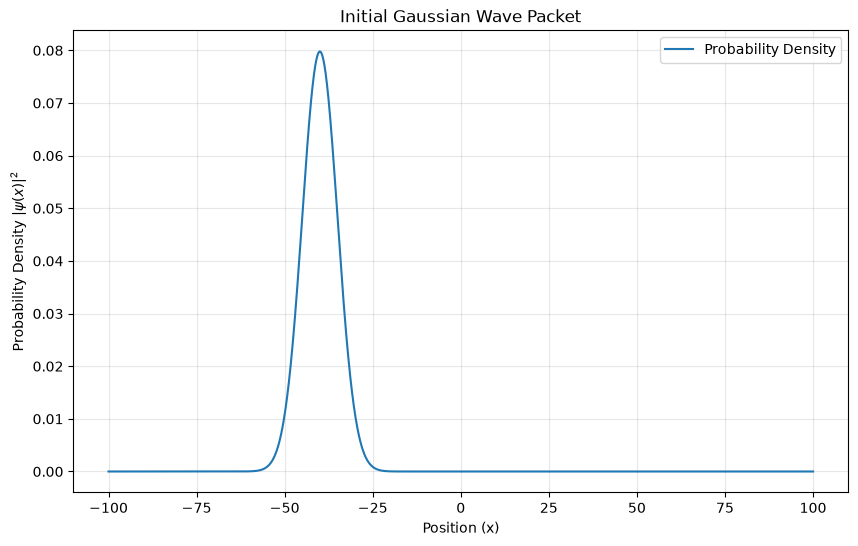

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(x, np.abs(psi)**2, label='Probability Density')
plt.xlabel('Position (x)')
plt.ylabel(r"Probability Density $|\psi(x)|^2$")
plt.title('Initial Gaussian Wave Packet')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

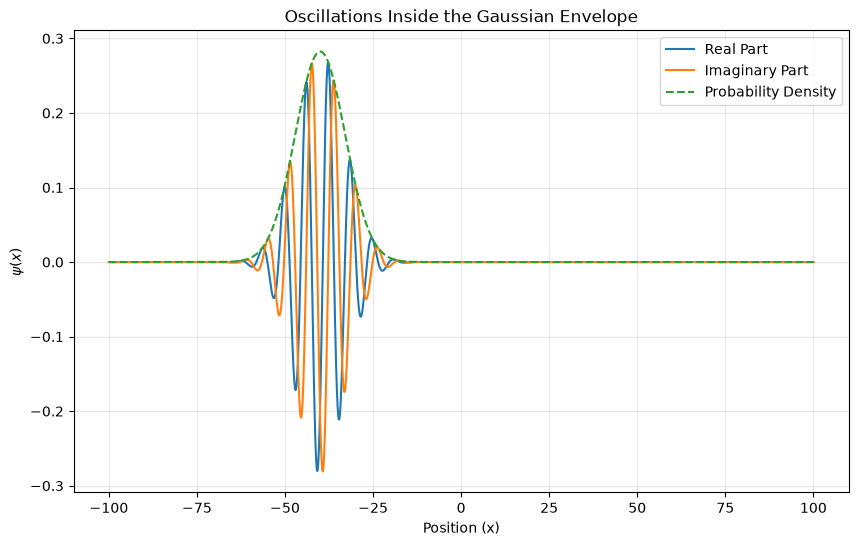

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(x, np.real(psi), label='Real Part')
plt.plot(x, np.imag(psi), label='Imaginary Part')
plt.plot(x, np.abs(psi), label='Probability Density', linestyle='--')
plt.xlabel('Position (x)')
plt.ylabel(r"$\psi(x)$")
plt.title('Oscillations Inside the Gaussian Envelope')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Experimenting with different values of k0 (k0 = 1, k0 = 2, k0 = 3, k0 = 6, k0 = 10), we observe that higher k0 values produce a Gaussian envelope containing oscillations of a higher frequency, showing that \psi(x) is more energetic. We also get the result \lambda = 2\pi / k, as the wavelength becomes shorter; it is inversely proportional to k.

In [31]:
from scipy.sparse import diags

main_diag = -2 * np.ones(N)
off_diag = np.ones(N - 1)
D2 = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1]) / dx**2

T = - (hbar**2 / (2 * m)) * D2